In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
books = pd.read_csv(
    r"Data Sets/archive/book crossing dataset/BX-CSV-Dump/BX-Books.csv",
    sep=";",
    on_bad_lines='skip',
    encoding='latin-1'
)
books.columns = ['ISBN',	'Book-Title',	'Book-Author',	'Year-Of-Publication'	,'Publisher',	'Image-URL-S'	,'Image-URL-M'	,'Image-URL-L']

users = pd.read_csv(
    r"E:\Pyhton code\Data Sets\archive\book crossing dataset\BX-CSV-Dump\BX-Users.csv",
    sep=";",
    on_bad_lines='skip',
    encoding='latin-1'
)
users.columns = ['User-ID','Location','Age']

ratings = pd.read_csv(
    r"E:\Pyhton code\Data Sets\archive\book crossing dataset\BX-CSV-Dump\BX-Book-Ratings.csv",
    sep=";",
    on_bad_lines='skip',
    encoding='latin-1'
)
ratings.columns = ['User-ID','ISBN','Book-Rating']

C:\Users\SUYASH\AppData\Local\Temp\ipykernel_12932\1522305582.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv(


In [3]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [4]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [5]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [6]:
print("Books shape:",books.shape)
print("User shape:", users.shape)
print("Ratings:", ratings.shape)

Books shape: (271360, 8)
User shape: (278858, 3)
Ratings: (1149780, 3)


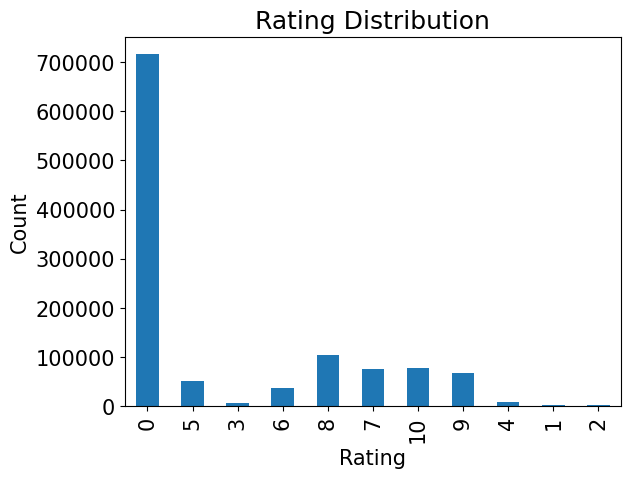

In [7]:
plt.rc("font", size=15)

ratings['Book-Rating'].value_counts(sort=False).plot(kind='bar')

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

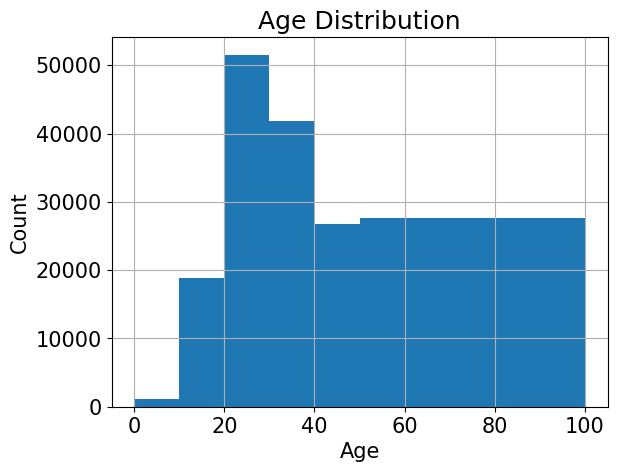

In [8]:
users.Age.hist(bins=[0,10,20,30,40,50,100])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [9]:
#To ensure statistical significance user with less than 200 ratings, and books with less than 100 rating are excluded.
counts1 = ratings['User-ID'].value_counts()
ratings = ratings[ratings['User-ID'].isin(counts1[counts1 >= 200].index)]
counts = ratings['Book-Rating'].value_counts()
ratings = ratings[ratings['Book-Rating'].isin(counts[counts >= 100].index)]

# Collaborative Filtering Using K-Nearest Neighbors

KNN is a ml algorithm to find clusters of similar users based on common book ratings and amke predictions using the average rating of top k nearest neighbours. For example, we first present rating in a matrix with the matrix having one row for each item (book) and one column for each user.

In [10]:
combine_book_rating = pd.merge(ratings, books, on='ISBN')
columns = ['Year-Of-Publication','Publisher','Book-Author','Image-URL-S','Image-URL-M','Image-URL-L']
combine_book_rating = combine_book_rating.drop(columns, axis=1)
combine_book_rating.head()

,User-ID,ISBN,Book-Rating,Book-Title
0,277427,002542730X,10,Politically Correct Bedtime Stories: Modern Ta...
1,277427,0026217457,0,Vegetarian Times Complete Cookbook
2,277427,003008685X,8,Pioneers
3,277427,0030615321,0,"Ask for May, Settle for June (A Doonesbury book)"
4,277427,0060002050,0,On a Wicked Dawn (Cynster Novels)


In [11]:
combine_book_rating = combine_book_rating.dropna(axis=0, subset=['Book-Title'])
book_ratingCount = (combine_book_rating.
                    groupby(by = ['Book-Title'])['Book-Rating'].
                    count().
                    reset_index().
                    rename(columns = {'Book-Rating':'totalRatingCount'})
                    [['Book-Title', 'totalRatingCount']]
                    )
book_ratingCount.head()

,Book-Title,totalRatingCount
0,A Light in the Storm: The Civil War Diary of ...,2
1,Always Have Popsicles,1
2,Apple Magic (The Collector's series),1
3,Beyond IBM: Leadership Marketing and Finance ...,1
4,Clifford Visita El Hospital (Clifford El Gran...,1


In [15]:
rating_with_totalRatingCount = combine_book_rating.merge(book_ratingCount, left_on='Book-Title', right_on='Book-Title', how='left')
rating_with_totalRatingCount.head()

,User-ID,ISBN,Book-Rating,Book-Title,totalRatingCount
0,277427,002542730X,10,Politically Correct Bedtime Stories: Modern Ta...,82
1,277427,0026217457,0,Vegetarian Times Complete Cookbook,7
2,277427,003008685X,8,Pioneers,1
3,277427,0030615321,0,"Ask for May, Settle for June (A Doonesbury book)",1
4,277427,0060002050,0,On a Wicked Dawn (Cynster Novels),13


In [16]:
popularity_threshold = 50
rating_popular_book = rating_with_totalRatingCount.query('totalRatingCount >= @popularity_threshold')
rating_popular_book.head()

,User-ID,ISBN,Book-Rating,Book-Title,totalRatingCount
0,277427,002542730X,10,Politically Correct Bedtime Stories: Modern Ta...,82
13,277427,0060930535,0,The Poisonwood Bible: A Novel,133
15,277427,0060934417,0,Bel Canto: A Novel,108
18,277427,0061009059,9,One for the Money (Stephanie Plum Novels (Pape...,108
24,277427,006440188X,0,The Secret Garden,79


In [17]:
rating_popular_book.shape

(62149, 5)

In [18]:
#filter users from usa and canada
combined = rating_popular_book.merge(users, left_on='User-ID', right_on='User-ID', how='left')
us_canada_user_rating = combined[combined['Location'].str.contains("usa|canada")]
us_canada_user_rating = us_canada_user_rating.drop('Age', axis=1)
us_canada_user_rating.head()

,User-ID,ISBN,Book-Rating,Book-Title,totalRatingCount,Location
0,277427,002542730X,10,Politically Correct Bedtime Stories: Modern Ta...,82,"gilbert, arizona, usa"
1,277427,0060930535,0,The Poisonwood Bible: A Novel,133,"gilbert, arizona, usa"
2,277427,0060934417,0,Bel Canto: A Novel,108,"gilbert, arizona, usa"
3,277427,0061009059,9,One for the Money (Stephanie Plum Novels (Pape...,108,"gilbert, arizona, usa"
4,277427,006440188X,0,The Secret Garden,79,"gilbert, arizona, usa"


# Cosine Similarity

In [19]:
#Convert into array
from scipy.sparse import csr_matrix
us_canada_user_rating = us_canada_user_rating.drop_duplicates(['User-ID', 'Book-Title'])
us_canada_user_rating_pivot = us_canada_user_rating.pivot(index='Book-Title', columns='User-ID', values='Book-Rating').fillna(0)
us_canada_user_rating_matrix = csr_matrix(us_canada_user_rating_pivot.values)

from sklearn.neighbors import NearestNeighbors
model_knn = NearestNeighbors(metric='cosine', algorithm='brute')
model_knn.fit(us_canada_user_rating_matrix)

,n_neighbors,5
,radius,1.0
,algorithm,'brute'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


In [21]:
us_canada_user_rating_pivot.head()

User-ID,254,2276,2766,2977,3363,4017,4385,6242,6251,6323,...,271448,271705,273979,274061,274308,274808,275970,277427,277639,278418
Book-Title,,,,,,,,,,,,,,,,,,,,,
1984,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1st to Die: A Novel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2nd Chance,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4 Blondes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
84 Charing Cross Road,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,10.0,0.0,0.0,0.0


In [22]:
query_index = np.random.choice(us_canada_user_rating_pivot.shape[0])
print("Query Index:", query_index)
distance, indices = model_knn.kneighbors(us_canada_user_rating_pivot.iloc[query_index, :].values.reshape(1, -1), n_neighbors=6)

Query Index: 487


In [23]:
query_vector = us_canada_user_rating_pivot.iloc[query_index, :].values.reshape(1, -1)

In [24]:
us_canada_user_rating_pivot.index[query_index]

'Table For Two'

In [25]:
for i in range(0, len(distance.flatten())):
    if i == 0:
        print("Recommendations for {0}:\n".format(us_canada_user_rating_pivot.index[query_index]))
    else:
        print("{0}: {1}, with distance of {2}:".format(i, us_canada_user_rating_pivot.index[indices.flatten()[i]], distance.flatten()[i]))

Recommendations for Table For Two:

1: Truly, Madly Manhattan, with distance of 0.44416254158020607:
2: Summer Pleasures, with distance of 0.5125304523104518:
3: Engaging The Enemy, with distance of 0.5336176453611992:
4: Face the Fire (Three Sisters Island Trilogy), with distance of 0.5654783988621116:
5: The Villa, with distance of 0.5705887917728212:


Report:

- Title: Book Recommendation Using Collaborative Filtering with KNN

- Dataset: Book-Crossing Dataset (Books shape: (271360, 8)
User shape: (278858, 3)
Ratings: (1149780, 3))

- Methodology:
  - Data Loading and Analysis:Load three datasets: books, users, and ratings. Analyze the data to understand the distribution of ratings and user behavior.

  - KNN Implementation: 
  Combined user rating of books into a user-item matrix. We used cosine similarity to measure the similarity between users based on their ratings on Us and Canada books. We then applied the KNN algorithm to find the k nearest neighbors for each user.

  - Prediction: For each user, we identified their k nearest neighbors and predicted their ratings for books they haven't rated yet by taking the average rating from their neighbors.

- Results:
Recommendations for Table For Two:

- 1: Truly, Madly Manhattan, with distance of 0.44416254158020607:
- 2: Summer Pleasures, with distance of 0.5125304523104518:
- 3: Engaging The Enemy, with distance of 0.5336176453611992:
- 4: Face the Fire (Three Sisters Island Trilogy), with distance of 0.5654783988621116:
- 5: The Villa, with distance of 0.5705887917728212: